plot the infor acc by LLM

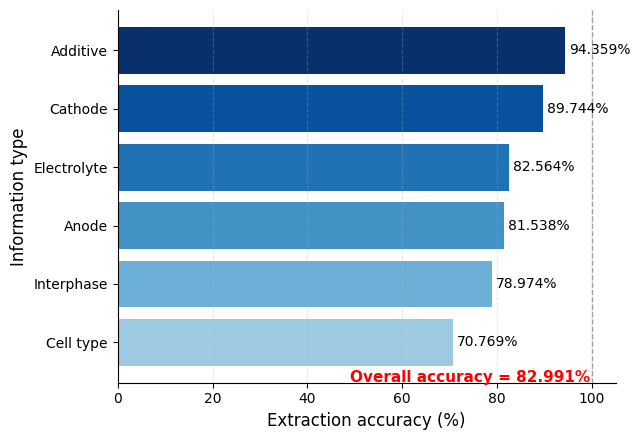

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Raw data
# =========================

total_count = 195

data = {
    "Cell type": 138,
    "Cathode": 175,
    "Anode": 159,
    "Additive": 184,
    "Electrolyte": 161,
    "Interphase": 154,
}

# =========================
# Calculate accuracy
# =========================

labels = list(data.keys())
correct = np.array(list(data.values()))
accuracy = correct / total_count * 100

# sort by accuracy
sorted_idx = np.argsort(accuracy)

labels = np.array(labels)[sorted_idx]
accuracy = accuracy[sorted_idx]

# overall accuracy
overall_accuracy = correct.sum() / (total_count * len(data)) * 100

# =========================
# Plot
# =========================

plt.figure(figsize=(6.5, 4.5))

# Nature-style blue gradient
colors = [
    "#9ecae1",
    "#6baed6",
    "#4292c6",
    "#2171b5",
    "#08519c",
    "#08306b",
]

colors = colors[:len(labels)]

bars = plt.barh(
    labels,
    accuracy,
    color=colors,
    linewidth=0.8
)

# Add accuracy text
for bar, acc in zip(bars, accuracy):
    plt.text(
        acc + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{acc:.3f}%",
        va="center",
        fontsize=10
    )

# dashed line at 100%
plt.axvline(
    100,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.7
)

# Labels
plt.xlabel("Extraction accuracy (%)", fontsize=12)
plt.ylabel("Information type", fontsize=12)

# Overall accuracy text
plt.text(
    49,
    -0.67,
    f"Overall accuracy = {overall_accuracy:.3f}%",
    fontsize=11,
    fontweight="bold",
    color='red'
)

# Limits
plt.xlim(0, 105)

# Style tweaks (Nature-like)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Tight layout
plt.tight_layout()

# # Save figure (recommended formats)
# plt.savefig("LLM_extraction_accuracy.pdf", dpi=600, bbox_inches="tight")
# plt.savefig("LLM_extraction_accuracy.png", dpi=600, bbox_inches="tight")

plt.show()


plot the distribution of molecules

节点数方差: 2235.46, 标准差: 47.28
边数方差: 10482.97, 标准差: 102.39


<Figure size 500x500 with 0 Axes>

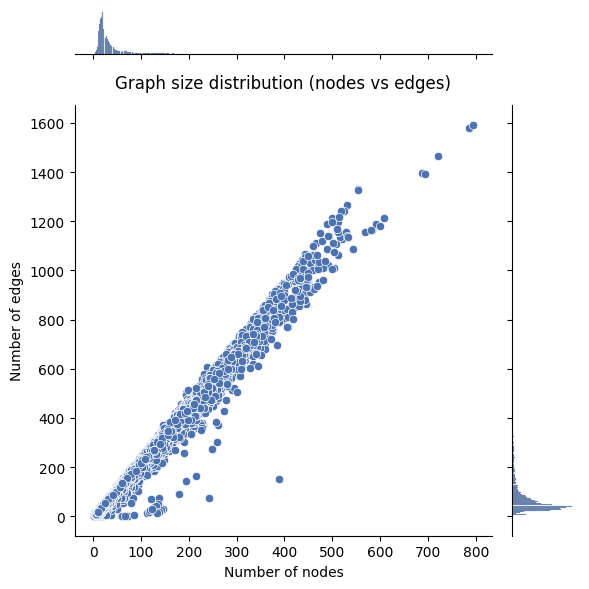

In [30]:
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

data_path = '../data/all_data.pkl'
with open(data_path, 'rb') as f:
    dataset = pickle.load(f)

node_counts = [data.num_nodes for data in dataset]
edge_counts = [data.num_edges for data in dataset]

# 计算方差与标准差
node_var = np.var(node_counts)
edge_var = np.var(edge_counts)

print(f"节点数方差: {node_var:.2f}, 标准差: {np.std(node_counts):.2f}")
print(f"边数方差: {edge_var:.2f}, 标准差: {np.std(edge_counts):.2f}")

# 简单可视化
plt.figure(figsize=(5,5))
sns.jointplot(x=node_counts, y=edge_counts, kind="scatter", color="#4C72B0")
plt.xlabel("Number of nodes")
plt.ylabel("Number of edges")
plt.title("Graph size distribution (nodes vs edges)", y=1.02)
plt.tight_layout()
plt.show()

plot 3D distribution: molecular weight, elements number, and years.

Loading positive samples data: 100%|██████████| 126/126 [00:00<00:00, 140.45it/s]


1996 2025


/tmp/ipykernel_673520/865095529.py:61: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  unlabeled_data = pd.read_csv('/home/hwx/python_project/test/Boron/data/searching_space_data_V2_old.csv')
Loading unlabeled data:  10%|█         | 18516/179977 [00:05<01:56, 1381.72it/s][15:11:05] Explicit valence for atom # 206 Br, 2, is greater than permitted
[15:11:05] WARNING: not removing hydrogen atom without neighbors
Loading unlabeled data:  10%|█         | 18765/179977 [00:05<01:45, 1531.23it/s][15:11:05] WARNING: not removing hydrogen atom without neighbors
[15:11:05] WARNING: not removing hydrogen atom without neighbors
[15:11:05] WARNING: not removing hydrogen atom without neighbors
[15:11:05] WARNING: not removing hydrogen atom without neighbors
[15:11:05] WARNING: not removing hydrogen atom without neighbors
[15:11:05] WARNING: not removing hydrogen atom without neighbors
[15:11:05] WARNING: not removing hydrogen atom without neighbor

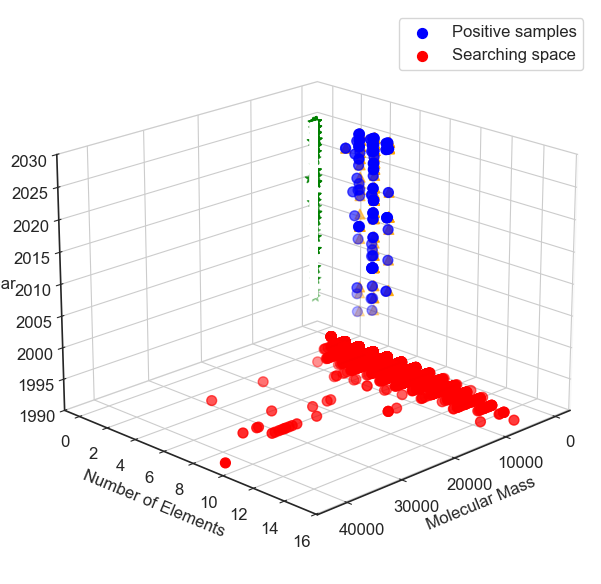

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import json
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
from tqdm import tqdm
import pickle
from rdkit.Contrib.SA_Score import sascorer

# 有年份的数据
with open('/home/hwx/python_project/test/Boron/V3/processed_data/additives.json', 'r') as f:
    additives_data = json.load(f)

additive_info_df = pd.read_excel('/home/hwx/python_project/test/Boron/V3/processed_data/20251011_additives_all_V2.xlsx')

mass_full = []
elements_full = []
year_full = []
SA_score_full = []

for key, value in tqdm(additives_data.items(), desc='Loading positive samples data'):
    smiles = value['smiles']
    mol = Chem.MolFromSmiles(smiles)
    mol_weight = Descriptors.MolWt(mol)
    SAScore = sascorer.calculateScore(mol)
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    num_elements = len(set(atoms))

    appear_year = []
    for idx, row in additive_info_df.iterrows():
        additives_name = row['additives_abbr']
        if key in additives_name:
            appear_year.append(row['years'])

    first_appear_year = min(appear_year)

    mass_full.append(mol_weight)
    elements_full.append(num_elements)
    year_full.append(first_appear_year)
    SA_score_full.append(SAScore)

mass_full = np.array(mass_full)
elements_full = np.array(elements_full)
year_full = np.array(year_full)
SA_score_full = np.array(SA_score_full)
with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_full.pkl', 'wb') as file:
    pickle.dump(SA_score_full, file)

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_full.pkl', 'rb') as file:
    mass_full = pickle.load(file)
with open('/home/hwx/python_project/test/Boron/V3/plot_data/elements_full.pkl', 'rb') as file:
    elements_full = pickle.load(file)
with open('/home/hwx/python_project/test/Boron/V3/plot_data/year_full.pkl', 'rb') as file:
    year_full = pickle.load(file)

print(year_full.min(), year_full.max())

# 无年份的数据
unlabeled_data = pd.read_csv('/home/hwx/python_project/test/Boron/data/searching_space_data_V2_old.csv')
mass_partial = []
elements_partial = []
SA_score_partial = []
for smiles in tqdm(unlabeled_data['SMILES'], desc='Loading unlabeled data'):
    mol = Chem.MolFromSmiles(smiles)
    try:
        mol_weight = Descriptors.MolWt(mol)
        SAScore = sascorer.calculateScore(mol)
    except:
        continue
    atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
    num_elements = len(set(atoms))

    mass_partial.append(mol_weight)
    elements_partial.append(num_elements)
    SA_score_partial.append(SAScore)

mass_partial = np.array(mass_partial)
elements_partial = np.array(elements_partial)
SA_score_partial = np.array(SA_score_partial)
with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_partial.pkl', 'wb') as file:
    pickle.dump(SA_score_partial, file)

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_partial.pkl', 'rb') as file:
    mass_partial = pickle.load(file)
with open('/home/hwx/python_project/test/Boron/V3/plot_data/elements_partial.pkl', 'rb') as file:
    elements_partial = pickle.load(file)


# 关键：统一放在 xy 平面


# ======================
# 创建3D图
# ======================

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# ======================
# plot 有年份数据
# ======================

ax.scatter(
    mass_full,
    elements_full,
    year_full,
    color='blue',
    s=50,
    label='Positive samples'
)

z_plane = 1990
y_plane = 0
x_plane = 0

# ======================
# plot 无年份数据（在xy平面）
# ======================

ax.scatter(
    mass_partial,
    elements_partial,
    z_plane,
    color='red',
    marker='o',
    s=50,
    label='Searching space'
)

# ======================
# 画xy平面（可选，更清晰）
# ======================

xx, yy = np.meshgrid(
    np.linspace(100, 350, 10),
    np.linspace(4, 14, 10)
)

zz = np.zeros_like(xx)

ax.plot_surface(
    xx, yy, zz,
    alpha=0.15,
    color='gray'
)

ax.plot_surface(xx, yy, zz, alpha=0.08, color='gray')

# xz平面
ax.scatter(
    mass_full,
    y_plane,
    year_full,
    color='green',
    marker='*',
    s=50,
)

xx, yy = np.meshgrid(
    np.linspace(mass_full.min(), mass_full.max(), 10),
    np.linspace(elements_full.min(), elements_full.max(), 10)
)

zz = np.full_like(xx, z_plane)

ax.plot_surface(
    xx, yy, zz,
    alpha=0.15,
    color='gray'
)


ax.plot_surface(xx, yy, zz, alpha=0.08, color='gray')


# yz平面
ax.scatter(
    x_plane,
    elements_full,
    year_full,
    color='orange',
    marker='^',
    s=50,
)

xx, zz = np.meshgrid(
    np.linspace(mass_full.min(), mass_full.max(), 10),
    np.linspace(year_full.min(), year_full.max(), 10)
)

yy = np.full_like(xx, y_plane)

ax.plot_surface(
    xx, yy, zz,
    alpha=0.15,
    color='gray'
)


ax.plot_surface(xx, yy, zz, alpha=0.08, color='gray')



ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# ======================
# 坐标轴
# ======================

ax.set_xlabel("Molecular Mass")
ax.set_ylabel("Number of Elements")
ax.set_zlabel("Year")


ax.set_zlim(1990, 2030)

# 视角调整
ax.view_init(elev=20, azim=45)

ax.legend()

plt.tight_layout()
plt.show()

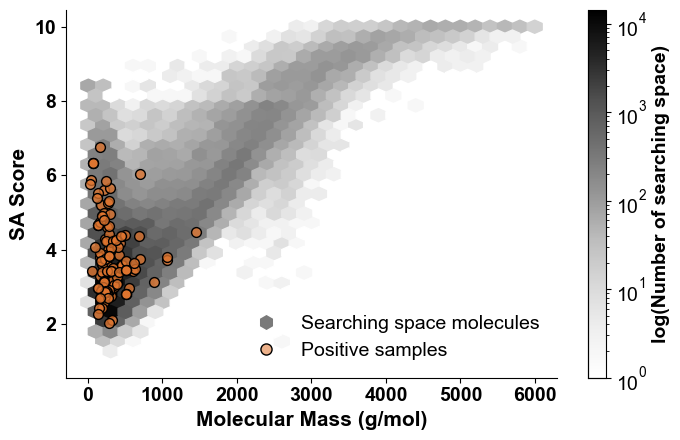

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ======================
# load data
# ======================

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_full.pkl', 'rb') as f:
    mass_full = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_full.pkl', 'rb') as f:
    sa_score_full = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/mass_partial.pkl', 'rb') as f:
    mass_partial = np.array(pickle.load(f))

with open('/home/hwx/python_project/test/Boron/V3/plot_data/sa_score_partial.pkl', 'rb') as f:
    sa_score_partial = np.array(pickle.load(f))

select_idx = np.where(mass_partial <= 6000)[0]
mass_partial = mass_partial[select_idx]
sa_score_partial = sa_score_partial[select_idx]


# ======================
# plot
# ======================
plt.figure(figsize=(7,4.5))
plt.rcParams['font.family'] = 'Arial'

# hexbin
hb = plt.hexbin(
    mass_partial,
    sa_score_partial,
    gridsize=30,
    cmap='Grays',
    bins='log',
    mincnt=1
)

# colorbar
cb = plt.colorbar(hb)
cb.ax.tick_params(labelsize=14)
cb.set_label('log(Number of searching space)', fontsize=14, fontweight='bold')

# scatter
sc = plt.scatter(
    mass_full,
    sa_score_full,
    color="#DF752FC7",
    s=50,
    marker='o',
    edgecolors='black',
    linewidth=1
)

# ===== 正确legend方法 =====

hex_color = hb.get_cmap()(0.6)

hex_legend = Line2D(
    [0], [0],
    marker='h',   # 六边形
    color='w',
    markerfacecolor=hex_color,
    markersize=12,
    linestyle='None',
    label='Searching space molecules'
)

# scatter legend proxy（圆形）
scatter_legend = Line2D(
    [0], [0],
    marker='o',
    color='w',
    markerfacecolor="#DF752F8F",
    markeredgecolor='black',
    markersize=8,
    linestyle='None',
    label='Positive samples'
)

plt.legend(handles=[hex_legend, scatter_legend], 
           loc='lower right',
           frameon=False,
           fontsize=14,
)

# labels
plt.xlabel("Molecular Mass (g/mol)", fontsize=15, fontweight='bold')
plt.ylabel("SA Score", fontsize=15, fontweight='bold')

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

sns.despine()

plt.tight_layout()
plt.savefig("../plots/SA_score_vs_mass.svg", dpi=600, bbox_inches="tight")
plt.show()